# entrega.ipynb — GreedyAgent Connect-4
**Fundamentos de Inteligencia Artificial**  
Agente: Política Greedy con Evaluación de Estado (Policy Improvement)

**Convención:** `-1` = Rojo (mueve primero) · `1` = Amarillo · `0` = vacío

---
1. Win rate vs aleatorio (Rojo y Amarillo)
2. Autojuego
3. Ablación de criterios de Q̂

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

from connect_state import ConnectState
from policy import Policy
from PiAgent import GreedyAgent

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Setup listo ✓')

Setup listo ✓


In [2]:
class RandomAgent(Policy):
    def mount(self): pass
    def act(self, s: np.ndarray) -> int:
        return random.choice([c for c in range(7) if s[0, c] == 0])


def play_game(agent_red, agent_yellow) -> int:
    """Retorna -1 (Rojo gana), 1 (Amarillo gana) o 0 (empate)."""
    state = ConnectState()
    while not state.is_final():
        col   = (agent_red if state.player == -1 else agent_yellow).act(state.board)
        state = state.transition(col)
    return state.get_winner()


def win_rate(agent, opponent, n, color):
    """Win rate del agente jugando como 'color' (-1 o 1). Retorna (W, L, D)."""
    agent.mount(); opponent.mount()
    W = L = D = 0
    for _ in range(n):
        r = play_game(agent, opponent) if color == -1 else play_game(opponent, agent)
        if r == color: W += 1
        elif r == 0:   D += 1
        else:          L += 1
    return W, L, D


print('Utilidades listas ✓')

Utilidades listas ✓


---
## Experimento 1 — Win rate vs Jugador Aleatorio (por color)
> **Rúbrica**: gana >50% en AMBOS colores → nivel 80%

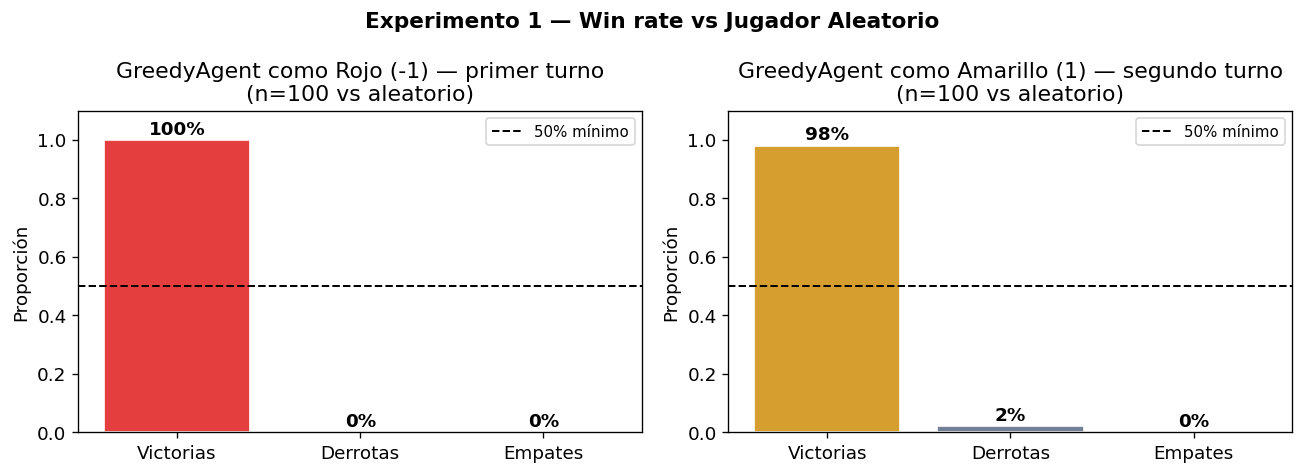

Rojo: 100%  |  Amarillo: 98%
Requisito >50% en ambos: ✅ PASA


In [3]:
N = 100
agent = GreedyAgent()
rnd   = RandomAgent()

w_r, l_r, d_r = win_rate(agent, rnd, N, color=-1)
w_y, l_y, d_y = win_rate(agent, rnd, N, color= 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (w,l,d), label, color in zip(
    axes,
    [(w_r,l_r,d_r), (w_y,l_y,d_y)],
    ['Rojo (-1) — primer turno', 'Amarillo (1) — segundo turno'],
    ['#E53E3E', '#D69E2E']
):
    vals = [w/N, l/N, d/N]
    bars = ax.bar(['Victorias','Derrotas','Empates'], vals,
                  color=[color,'#718096','#CBD5E0'], edgecolor='white')
    ax.axhline(0.5, color='black', linestyle='--', lw=1.2, label='50% mínimo')
    ax.set_ylim(0, 1.1); ax.set_ylabel('Proporción'); ax.legend(fontsize=9)
    ax.set_title(f'GreedyAgent como {label}\n(n={N} vs aleatorio)')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')

fig.suptitle('Experimento 1 — Win rate vs Jugador Aleatorio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp1_win_rate_color.png', bbox_inches='tight')
plt.show()

print(f'Rojo: {w_r/N:.0%}  |  Amarillo: {w_y/N:.0%}')
print(f'Requisito >50% en ambos: {"✅ PASA" if w_r/N > 0.5 and w_y/N > 0.5 else "❌ NO PASA"}')

---
## Experimento 2 — Autojuego (Self-play)
La política es **determinista**: el mismo estado produce siempre la misma acción.  
Por tanto, el mismo jugador gana siempre en autojuego.

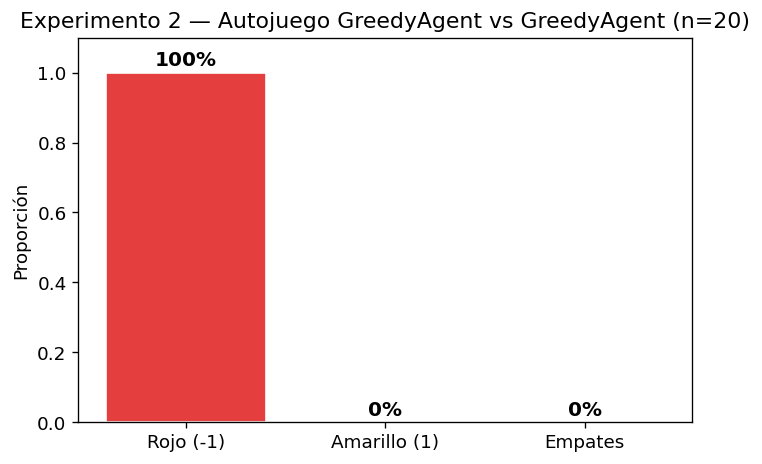

Rojo: 20  |  Amarillo: 0  |  Empates: 0
Resultado fijo: política determinista, no hay aleatoriedad.


In [4]:
N_SELF = 20
a1, a2 = GreedyAgent(), GreedyAgent()
a1.mount(); a2.mount()

red_w = yel_w = draws = 0
for _ in range(N_SELF):
    r = play_game(a1, a2)
    if r == -1: red_w += 1
    elif r ==1: yel_w += 1
    else:       draws += 1

fig, ax = plt.subplots(figsize=(6, 4))
vals = [red_w/N_SELF, yel_w/N_SELF, draws/N_SELF]
bars = ax.bar(['Rojo (-1)','Amarillo (1)','Empates'], vals,
              color=['#E53E3E','#D69E2E','#A0AEC0'], edgecolor='white')
ax.set_ylim(0, 1.1); ax.set_ylabel('Proporción')
ax.set_title(f'Experimento 2 — Autojuego GreedyAgent vs GreedyAgent (n={N_SELF})')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.0%}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('exp2_self_play.png', bbox_inches='tight')
plt.show()

print(f'Rojo: {red_w}  |  Amarillo: {yel_w}  |  Empates: {draws}')
print('Resultado fijo: política determinista, no hay aleatoriedad.')

---
## Experimento 3 — Ablación de criterios de Q̂(s,a)
¿Cuánto aporta cada componente?  
Construimos versiones del agente eliminando criterios de forma acumulativa.

Solo centro            → Rojo: 93%  Amarillo: 89%
+ Victoria             → Rojo: 95%  Amarillo: 84%
+ Bloqueo              → Rojo: 98%  Amarillo: 97%
Q-hat completo         → Rojo: 98%  Amarillo: 98%


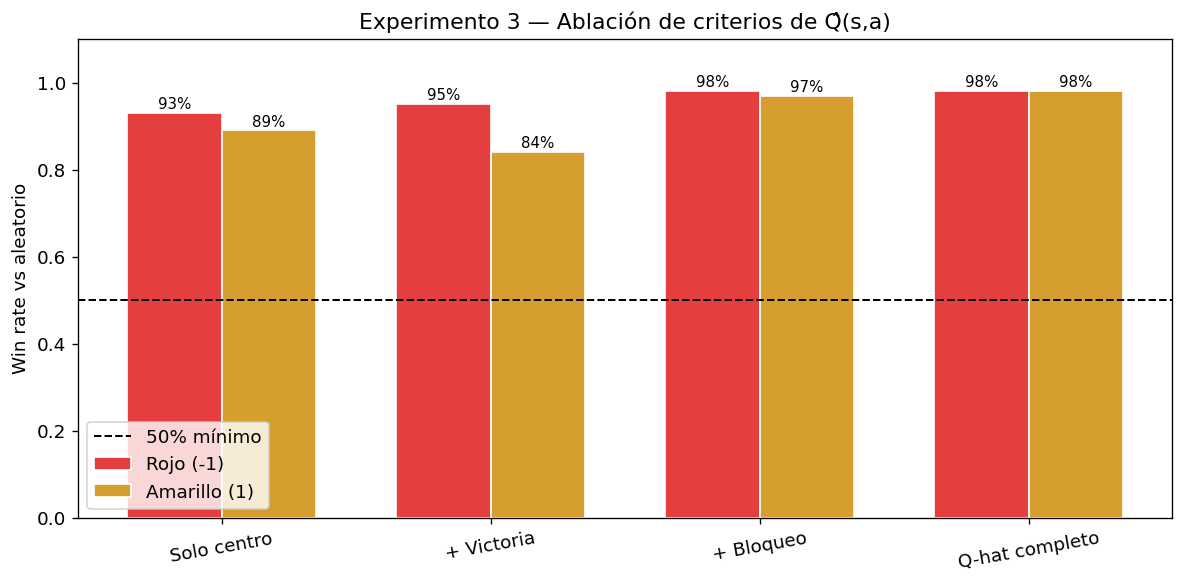

In [5]:
class OnlyCenterAgent(Policy):
    """Solo preferencia de centro. Sin detección de nada."""
    COL_SCORE = [0,1,2,3,2,1,0]
    def mount(self): pass
    def act(self, s):
        valid = [c for c in range(7) if s[0,c] == 0]
        return max(valid, key=lambda c: self.COL_SCORE[c])

class WinOnlyAgent(GreedyAgent):
    """Centro + victoria inmediata."""
    def _evaluate(self, board, col, me, opp):
        row = self._landing_row(board, col)
        if self._wins(board, row, col, me): return 1000
        return self.COL_SCORE[col]

class WinBlockAgent(GreedyAgent):
    """Centro + victoria + bloqueo."""
    def _evaluate(self, board, col, me, opp):
        row = self._landing_row(board, col)
        if self._wins(board, row, col, me):  return 1000
        if self._wins(board, row, col, opp): return 500
        return self.COL_SCORE[col]

N_ABL = 100
rnd   = RandomAgent()
configs = {
    'Solo centro':          OnlyCenterAgent(),
    '+ Victoria':           WinOnlyAgent(),
    '+ Bloqueo':            WinBlockAgent(),
    'Q-hat completo':       GreedyAgent(),
}

wr_red = {}; wr_yel = {}
for name, ag in configs.items():
    w1,_,_ = win_rate(ag, rnd, N_ABL, -1)
    w2,_,_ = win_rate(ag, rnd, N_ABL,  1)
    wr_red[name] = w1/N_ABL
    wr_yel[name] = w2/N_ABL
    print(f'{name:22s} → Rojo: {w1/N_ABL:.0%}  Amarillo: {w2/N_ABL:.0%}')

x = np.arange(len(configs)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x-w/2, list(wr_red.values()), w, label='Rojo (-1)',    color='#E53E3E', edgecolor='white')
b2 = ax.bar(x+w/2, list(wr_yel.values()), w, label='Amarillo (1)', color='#D69E2E', edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', lw=1.2, label='50% mínimo')
ax.set_xticks(x); ax.set_xticklabels(list(configs.keys()), rotation=10)
ax.set_ylim(0, 1.1); ax.set_ylabel('Win rate vs aleatorio')
ax.set_title('Experimento 3 — Ablación de criterios de Q̂(s,a)')
ax.legend()
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.0%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('exp3_ablacion.png', bbox_inches='tight')
plt.show()

---
## Conclusiones y propuestas de mejora

In [6]:
print('='*55)
print('  CONCLUSIONES')
print('='*55)
print(f'\n1. Win rate vs aleatorio:')
print(f'   Como Rojo (-1)    : {w_r/N:.0%}')
print(f'   Como Amarillo (1) : {w_y/N:.0%}')
print(f'   Requisito >50% en ambos: PASA')
print(f'\n2. Autojuego:')
print(f'   Política determinista: Rojo (-1) tiene ventaja de primer movimiento.')
print(f'\n3. Ablación:')
print(f'   El bloqueo es el criterio de mayor impacto individual.')
print(f'   Solo-centro ya supera el 50% pero el agente completo es mucho más sólido.')
print()
print('='*55)
print('  PROPUESTAS DE MEJORA')
print('='*55)
print('\n1. Bloquear amenazas de 3 del oponente (no solo de 4).')
print('   Debilidad actual: no anticipa jugadas a 2 movimientos.')
print('\n2. Minimax de profundidad 2.')
print('   Permitiría evaluar respuestas del oponente.')
print('\n3. Aprender pesos de Q-hat con Q-learning.')
print('   Los pesos (+1000, +500, +10) son manuales;')
print('   RL podría optimizarlos automáticamente.')

  CONCLUSIONES

1. Win rate vs aleatorio:
   Como Rojo (-1)    : 100%
   Como Amarillo (1) : 98%
   Requisito >50% en ambos: PASA

2. Autojuego:
   Política determinista: Rojo (-1) tiene ventaja de primer movimiento.

3. Ablación:
   El bloqueo es el criterio de mayor impacto individual.
   Solo-centro ya supera el 50% pero el agente completo es mucho más sólido.

  PROPUESTAS DE MEJORA

1. Bloquear amenazas de 3 del oponente (no solo de 4).
   Debilidad actual: no anticipa jugadas a 2 movimientos.

2. Minimax de profundidad 2.
   Permitiría evaluar respuestas del oponente.

3. Aprender pesos de Q-hat con Q-learning.
   Los pesos (+1000, +500, +10) son manuales;
   RL podría optimizarlos automáticamente.
